In [29]:
import kagglehub
import pandas as pd

TARGET = 'tceq'
DROP_COLS = ['ecoregion_type', 'zone_name', 'country_name', 'region', 'continent']

# mexico dataset
mexico_dataset = kagglehub.dataset_download("itsmrmallik/tf-countries", path="Mexico_wosis_merged(in)_temp_precip_landcover(in)_ecoregions(in).csv")
mexico = pd.read_csv(mexico_dataset)

print(f"Columns in Mexico dataset: {mexico.columns}")

# drop not relevant columns
mexico = mexico.drop(columns=DROP_COLS)

# drop rows with missing values in target column
mexico = mexico.dropna(subset=[TARGET])

# drop columns with 60% of missing values
mexico = mexico.dropna(thresh=0.6*len(mexico), axis=1)

# drop duplicate rows
mexico = mexico.drop_duplicates()

# drop other missing values
mexico = mexico.dropna()

print("-"*15, "Final Dataset", "-"*15)
print(f"Columns in dataset: {mexico.columns}")
print(f"Shape of dataset: {mexico.shape}")
print("-"*30)

# save dataset
mexico_path = f"D:/tierra/data/mexico_{TARGET}_dataset.csv"
mexico.to_csv(mexico_path, index=False)

# display dataset
mexico.head()

Columns in Mexico dataset: Index(['date', 'longitude', 'latitude', 'upper_depth', 'lower_depth',
       'country_name', 'region', 'continent', 'bdfi33', 'bdfiod', 'bdwsod',
       'cecph7', 'cfgr', 'cfvo', 'clay', 'ecec', 'elco20', 'elcosp', 'nitkjd',
       'orgc', 'phaq', 'phca', 'phetb1', 'phkc', 'phnf', 'phprtn', 'sand',
       'silt', 'tceq', 'totc', 'wg0010', 'wg0033', 'wg0200', 'wg1500',
       'temperature', 'precipitation', 'landcover', 'ecoregion_type',
       'zone_number', 'zone_name'],
      dtype='object')
--------------- Final Dataset ---------------
Columns in dataset: Index(['date', 'longitude', 'latitude', 'upper_depth', 'lower_depth', 'clay',
       'elcosp', 'orgc', 'phaq', 'sand', 'silt', 'tceq', 'temperature',
       'precipitation', 'landcover', 'zone_number'],
      dtype='object')
Shape of dataset: (1709, 16)
------------------------------


,date,longitude,latitude,upper_depth,lower_depth,clay,elcosp,orgc,phaq,sand,silt,tceq,temperature,precipitation,landcover,zone_number
2043,6/11/2001,-115.072010,31.415775,0,10,3.0,0.1,18.0,8.1,95.0,2.0,5.0,16.924751,150.516754,10.0,5
2053,6/12/2001,-111.335570,31.122982,0,23,22.0,0.1,2.0,8.7,56.0,22.0,10.0,16.924751,150.516754,7.0,5
2054,6/12/2001,-110.948906,31.120768,0,20,12.0,0.1,6.0,5.5,72.0,16.0,0.0,16.924751,150.516754,10.0,4
2055,6/12/2001,-110.095820,31.055500,0,20,32.0,0.1,7.0,6.4,54.0,14.0,0.0,16.924751,150.516754,7.0,5
2057,6/13/2001,-110.830600,31.307426,0,15,20.0,0.2,11.0,6.4,64.0,16.0,0.0,16.924751,150.516754,10.0,5


In [30]:
import geopandas as gpd
import pandas as pd

# import rock fragments
rock_fragments_0_5 = gpd.read_file("D:/tierra/data/rockfragments/cfr_05cm.geojson")
rock_fragments_5_15 = gpd.read_file("D:/tierra/data/rockfragments/cfr_15cm.geojson")
rock_fragments_15_30 = gpd.read_file("D:/tierra/data/rockfragments/cfr_15cm.geojson")

# create a new geo-dataframe with columns as geometry and cfr
rock_fragments = pd.concat([rock_fragments_0_5[['geometry', '_mean']],
                            rock_fragments_5_15[['geometry', '_mean']],
                            rock_fragments_15_30[['geometry', '_mean']]], ignore_index=True)

rock_fragments = gpd.GeoDataFrame(rock_fragments, geometry='geometry')

# save rock fragments
rock_fragments_path = f"D:/tierra/data/rock_{TARGET}_fragments.csv"
rock_fragments.to_csv(rock_fragments_path, index=False)

rock_fragments.head()


,geometry,_mean
0,"MULTIPOLYGON (((-114.72558 32.72561, -114.7159...",3.350253
1,"MULTIPOLYGON (((-114.85062 32.71599, -114.841 ...",3.426273
2,"MULTIPOLYGON (((-114.841 32.71599, -114.83138 ...",5.800558
3,"MULTIPOLYGON (((-114.83138 32.71599, -114.8217...",7.194875
4,"MULTIPOLYGON (((-114.81215 32.71599, -114.8025...",4.980327


In [31]:
import geopandas as gpd
import pandas as pd

#convert mexico dataset to geodataframe
mexico_path = f"D:/tierra/data/mexico_{TARGET}_dataset.csv"
mexico = pd.read_csv(mexico_path)
mex_gdf = gpd.GeoDataFrame(mexico, crs="epsg:4326", geometry=gpd.points_from_xy(mexico.longitude, mexico.latitude))

slope_df = gpd.read_file("D:/tierra/data/soil/slope.geojson")
slope_df = slope_df[['geometry', 'slopemean']]
slope_df = gpd.GeoDataFrame(slope_df, geometry='geometry')
print(slope_df.head())

# merge with mexico dataset
mex_gdf = gpd.sjoin(mex_gdf, slope_df, how='left', predicate='within')

# drop columns
mex_gdf = mex_gdf.drop(columns=['index_right'])

mex_gdf.head()

                                            geometry  slopemean
0  POLYGON ((-114.87791 32.71451, -114.87791 32.7...   1.938238
1  POLYGON ((-114.85794 32.71451, -114.85794 32.7...   0.385698
2  POLYGON ((-114.87791 32.70452, -114.87791 32.6...   0.399012
3  POLYGON ((-114.78804 32.71451, -114.78804 32.7...   0.311321
4  POLYGON ((-114.82798 32.69454, -114.82798 32.6...   0.348512


,date,longitude,latitude,upper_depth,lower_depth,clay,elcosp,orgc,phaq,sand,silt,tceq,temperature,precipitation,landcover,zone_number,geometry,slopemean
0,6/11/2001,-115.072010,31.415775,0,10,3.0,0.1,18.0,8.1,95.0,2.0,5.0,16.924751,150.516754,10.0,5,POINT (-115.07201 31.41578),1.012489
1,6/12/2001,-111.335570,31.122982,0,23,22.0,0.1,2.0,8.7,56.0,22.0,10.0,16.924751,150.516754,7.0,5,POINT (-111.33557 31.12298),3.104057
2,6/12/2001,-110.948906,31.120768,0,20,12.0,0.1,6.0,5.5,72.0,16.0,0.0,16.924751,150.516754,10.0,4,POINT (-110.94891 31.12077),2.679646
3,6/12/2001,-110.095820,31.055500,0,20,32.0,0.1,7.0,6.4,54.0,14.0,0.0,16.924751,150.516754,7.0,5,POINT (-110.09582 31.0555),0.959081
4,6/13/2001,-110.830600,31.307426,0,15,20.0,0.2,11.0,6.4,64.0,16.0,0.0,16.924751,150.516754,10.0,5,POINT (-110.8306 31.30743),1.089010


In [32]:
soil_type_df = gpd.read_file("D:/tierra/data/soil/soiltype.geojson")
soil_type_df = soil_type_df[['geometry', 'DESCRIPCIO']]
soil_type_df = gpd.GeoDataFrame(soil_type_df, geometry='geometry')
print(soil_type_df.head())

# merge with mexico dataset
mex_gdf = gpd.sjoin(mex_gdf, soil_type_df, how='left', predicate='within')

# drop columns
mex_gdf = mex_gdf.drop(columns=['index_right'])
mex_gdf.head()

                                            geometry         DESCRIPCIO
0  MULTIPOLYGON (((-114.75709 32.71366, -114.7204...            LITOSOL
1  MULTIPOLYGON (((-114.75199 32.70363, -114.7551...    REGOSOL EUTRICO
2  MULTIPOLYGON (((-114.72629 32.70524, -114.7285...  REGOSOL CALCARICO
3  MULTIPOLYGON (((-114.88829 32.66793, -114.8852...   VERTISOL CROMICO
4  MULTIPOLYGON (((-115.51851 32.66126, -115.4158...               None


,date,longitude,latitude,upper_depth,lower_depth,clay,elcosp,orgc,phaq,sand,silt,tceq,temperature,precipitation,landcover,zone_number,geometry,slopemean,DESCRIPCIO
0,6/11/2001,-115.072010,31.415775,0,10,3.0,0.1,18.0,8.1,95.0,2.0,5.0,16.924751,150.516754,10.0,5,POINT (-115.07201 31.41578),1.012489,FLUVISOL CALCARICO
1,6/12/2001,-111.335570,31.122982,0,23,22.0,0.1,2.0,8.7,56.0,22.0,10.0,16.924751,150.516754,7.0,5,POINT (-111.33557 31.12298),3.104057,LITOSOL
2,6/12/2001,-110.948906,31.120768,0,20,12.0,0.1,6.0,5.5,72.0,16.0,0.0,16.924751,150.516754,10.0,4,POINT (-110.94891 31.12077),2.679646,REGOSOL EUTRICO
3,6/12/2001,-110.095820,31.055500,0,20,32.0,0.1,7.0,6.4,54.0,14.0,0.0,16.924751,150.516754,7.0,5,POINT (-110.09582 31.0555),0.959081,FEOZEM HAPLICO
4,6/13/2001,-110.830600,31.307426,0,15,20.0,0.2,11.0,6.4,64.0,16.0,0.0,16.924751,150.516754,10.0,5,POINT (-110.8306 31.30743),1.089010,FEOZEM HAPLICO


In [33]:
# disable column limit
pd.set_option('display.max_columns', None)

# Load and prepare bedrock data
bedrock_df = gpd.read_file("D:/tierra/data/soil/bedrock.geojson")
bedrock_df = bedrock_df[['geometry', 'layer']]

# Convert both dataframes to a projected CRS (UTM Zone appropriate for Mexico)
bedrock_df = bedrock_df.to_crs("EPSG:32614")  # UTM Zone 14N (Central Mexico)
mex_gdf = mex_gdf.to_crs("EPSG:32614")

# Perform spatial join with nearest neighbor
mex_gdf = gpd.sjoin_nearest(mex_gdf, bedrock_df, how='left')

# Drop unnecessary columns and convert back to WGS84
mex_gdf = mex_gdf.drop(columns=['index_right']).to_crs("EPSG:4326")

mex_gdf.head()

,date,longitude,latitude,upper_depth,lower_depth,clay,elcosp,orgc,phaq,sand,silt,tceq,temperature,precipitation,landcover,zone_number,geometry,slopemean,DESCRIPCIO,layer
0,6/11/2001,-115.072010,31.415775,0,10,3.0,0.1,18.0,8.1,95.0,2.0,5.0,16.924751,150.516754,10.0,5,POINT (-115.07201 31.41577),1.012489,FLUVISOL CALCARICO,rocas_sedimentarias
1,6/12/2001,-111.335570,31.122982,0,23,22.0,0.1,2.0,8.7,56.0,22.0,10.0,16.924751,150.516754,7.0,5,POINT (-111.33557 31.12298),3.104057,LITOSOL,rocas_igneas
2,6/12/2001,-110.948906,31.120768,0,20,12.0,0.1,6.0,5.5,72.0,16.0,0.0,16.924751,150.516754,10.0,4,POINT (-110.94891 31.12077),2.679646,REGOSOL EUTRICO,rocas_metamorficas
3,6/12/2001,-110.095820,31.055500,0,20,32.0,0.1,7.0,6.4,54.0,14.0,0.0,16.924751,150.516754,7.0,5,POINT (-110.09582 31.0555),0.959081,FEOZEM HAPLICO,rocas_sedimentarias
4,6/13/2001,-110.830600,31.307426,0,15,20.0,0.2,11.0,6.4,64.0,16.0,0.0,16.924751,150.516754,10.0,5,POINT (-110.8306 31.30743),1.089010,FEOZEM HAPLICO,rocas_sedimentarias


In [34]:
# Load rock fragments
rock_fragments = pd.read_csv(f"D:/tierra/data/rock_{TARGET}_fragments.csv")

# Ensure rock_fragments is a GeoDataFrame with proper geometry
rock_fragments = gpd.GeoDataFrame(rock_fragments, geometry=gpd.GeoSeries.from_wkt(rock_fragments['geometry']))

# Rename rock fragments column
rock_fragments = rock_fragments.rename(columns={'_mean': 'rock_fragments'})

# Set CRS for rock_fragments to match mexico
rock_fragments.set_crs(epsg=4326, inplace=True)

# Merge datasets
gdf = gpd.sjoin(mex_gdf, rock_fragments, how='left', predicate='within')

# Drop geometry and index_right columns
gdf = gdf.drop(columns=['index_right'])

gdf.head()

,date,longitude,latitude,upper_depth,lower_depth,clay,elcosp,orgc,phaq,sand,silt,tceq,temperature,precipitation,landcover,zone_number,geometry,slopemean,DESCRIPCIO,layer,rock_fragments
0,6/11/2001,-115.07201,31.415775,0,10,3.0,0.1,18.0,8.1,95.0,2.0,5.0,16.924751,150.516754,10.0,5,POINT (-115.07201 31.41577),1.012489,FLUVISOL CALCARICO,rocas_sedimentarias,18.449413
0,6/11/2001,-115.07201,31.415775,0,10,3.0,0.1,18.0,8.1,95.0,2.0,5.0,16.924751,150.516754,10.0,5,POINT (-115.07201 31.41577),1.012489,FLUVISOL CALCARICO,rocas_sedimentarias,15.816959
0,6/11/2001,-115.07201,31.415775,0,10,3.0,0.1,18.0,8.1,95.0,2.0,5.0,16.924751,150.516754,10.0,5,POINT (-115.07201 31.41577),1.012489,FLUVISOL CALCARICO,rocas_sedimentarias,15.816959
1,6/12/2001,-111.33557,31.122982,0,23,22.0,0.1,2.0,8.7,56.0,22.0,10.0,16.924751,150.516754,7.0,5,POINT (-111.33557 31.12298),3.104057,LITOSOL,rocas_igneas,24.819817
1,6/12/2001,-111.33557,31.122982,0,23,22.0,0.1,2.0,8.7,56.0,22.0,10.0,16.924751,150.516754,7.0,5,POINT (-111.33557 31.12298),3.104057,LITOSOL,rocas_igneas,23.972266


In [35]:
gdf_path = f"D:/tierra/datasets/mexico_{TARGET}_dataset_add_soil_features.geojson"

In [36]:
# rename column names
gdf.rename(columns={'DESCRIPCIO': 'soil_type', 'layer': 'bedrock', 'zone_number': 'ecoregion'}, inplace=True)

print('Unique Soil Types', gdf['soil_type'].unique().tolist())
print('Unique Bedrock Types', gdf['bedrock'].unique().tolist())
print('Unique Eco Regions', gdf['ecoregion'].unique().tolist())

# replace values in ecoregion column
gdf['ecoregion'] = gdf['ecoregion'].replace({'VII': '7', 'VI': '6'})

# save mexico dataset
gdf.to_file(gdf_path, driver='GeoJSON')
print("Saved to file", gdf_path)

Unique Soil Types ['FLUVISOL CALCARICO', 'LITOSOL', 'REGOSOL EUTRICO', 'FEOZEM HAPLICO', 'XEROSOL CALCICO', 'PLANOSOL EUTRICO', 'VERTISOL CROMICO', 'XEROSOL HAPLICO', 'REGOSOL CALCARICO', 'ANDOSOL HUMICO', 'LUVISOL CROMICO', 'LUVISOL FERRICO', 'CAMBISOL CALCICO (calcarico)', 'REGOSOL DISTRICO', 'YERMOSOL CALCICO', 'YERMOSOL LUVICO', 'YERMOSOL HAPLICO', 'XEROSOL LUVICO', 'ANDOSOL OCRICO', 'CASTAÑOZEM LUVICO', 'CAMBISOL EUTRICO', 'CAMBISOL HUMICO', 'FLUVISOL DISTRICO', 'ACRISOL ORTICO', 'HISTOSOL EUTRICO', 'SOLONCHAK ORTICO', 'LUVISOL ORTICO', 'FEOZEM LUVICO', 'RENDZINA', 'ACRISOL HUMICO', 'NITOSOL DISTRICO', 'VERTISOL PELICO', 'CAMBISOL CROMICO', 'LUVISOL VERTICO', 'FEOZEM CALCARICO', 'PLANOSOL MOLICO', 'ANDOSOL MOLICO', 'CAMBISOL DISTRICO', 'CAMBISOL FERRALICO', 'NITOSOL EUTRICO', 'GLEYSOL VERTICO', 'FLUVISOL EUTRICO', 'SOLONCHAK GLEYICO', 'CASTAÑOSEM  HAPLICO', nan, 'SOLONCHAK TAKIRICO', 'SOLONCHAK MOLICO', 'CASTAÑOZEM CALCICO', 'GLEYSOL PLINTICO', 'LUVISOL PLINTICO', 'XEROSOL GYPSICO

In [37]:
import geopandas as gpd
import pandas as pd

# load final dataset
final_dataset = gpd.read_file(gdf_path)
print("Shape of the dataset", final_dataset.shape)

# drop spatial columns
# final_dataset.drop(columns=['latitude', 'longitude', 'date'], inplace=True)

# drop duplicate rows
final_dataset = final_dataset.drop_duplicates().reset_index(drop=True)
print("Shape of the dataset after dropping duplicates", final_dataset.shape)

# drop rows with same values in all columns except rock_fragments and get mean of rock_fragments
final_dataset = final_dataset.groupby(final_dataset.columns.difference(['rock_fragments']).tolist(), as_index=False).agg({'rock_fragments': 'mean'}).reset_index(drop=True)
print("Shape of the dataset", final_dataset.shape)

def om_bd_columns(df):
    """
    Calculate organic matter and bulk density columns based on the 'orgc' column in the DataFrame.
    @param df - The DataFrame containing the 'orgc' column
    @return The DataFrame with added columns for organic matter and bulk density
    """
    if 'orgc' in df.columns:
        # Use vectorized operations for better performance
        organic_matter = 1.724 * df['orgc']
        df = df.assign(
            organic_matter=organic_matter,
            bulk_density=1.62 - 0.06 * organic_matter
        )
    
    return df

# Handle silt and clay columns if present
def silt_plus_clay_columns(df):
    """
    Combine the 'silt' and 'clay' columns in the DataFrame by summing them up and creating a new column 'silt_plus_clay'. Then, drop the 'silt' and 'clay' columns from the DataFrame.
    @param df - The DataFrame containing 'silt' and 'clay' columns
    @return The modified DataFrame with a new column 'silt_plus_clay' and without 'silt' and 'clay' columns.
    """
    if {'silt', 'clay'}.issubset(df.columns):
        df['silt_plus_clay'] = df[['silt', 'clay']].sum(axis=1, skipna=True)
        df.drop(columns=['silt', 'clay'], inplace=True)
    return df

# add organic matter and bulk density columns
final_dataset = om_bd_columns(final_dataset)

# sum silt and clay columns
final_dataset = silt_plus_clay_columns(final_dataset)

final_dataset.head()

Shape of the dataset (5809, 21)
Shape of the dataset after dropping duplicates (3421, 21)
Shape of the dataset (1704, 21)


,bedrock,date,ecoregion,elcosp,geometry,landcover,latitude,longitude,lower_depth,orgc,phaq,precipitation,sand,slopemean,soil_type,tceq,temperature,upper_depth,rock_fragments,organic_matter,bulk_density,silt_plus_clay
0,rocas_igneas,11/14/2003,2,0.0,POINT (-99.68626 16.71785),17.0,16.717850,-99.686264,30,3.0,5.3,22.056425,92.0,0.150130,SOLONCHAK GLEYICO,0.0,13.048712,0,0.009315,5.172,1.30968,8.0
1,rocas_igneas,9/18/2002,7,0.1,POINT (-104.65806 19.17316),2.0,19.173162,-104.658060,12,8.0,6.6,163.591797,95.0,0.796442,REGOSOL EUTRICO,0.0,16.481157,0,6.378134,13.792,0.79248,5.0
2,rocas_igneas,11/13/2003,2,0.1,POINT (-98.49142 18.89119),8.0,18.891191,-98.491420,30,3.0,6.1,22.056425,90.0,1.919764,FLUVISOL EUTRICO,0.0,13.048712,0,6.225403,5.172,1.30968,10.0
3,rocas_igneas,8/26/2003,2,0.8,POINT (-104.8642 21.07363),10.0,21.073630,-104.864200,13,31.0,6.6,155.092468,82.0,5.415294,REGOSOL EUTRICO,0.0,16.817062,0,9.413166,53.444,-1.58664,18.0
4,rocas_igneas,8/23/2003,2,0.1,POINT (-105.04132 20.84146),12.0,20.841465,-105.041320,8,6.0,5.9,155.092468,90.0,1.690705,FEOZEM HAPLICO,0.0,16.817062,0,12.961844,10.344,0.99936,10.0


In [38]:
def apply_horizon_depth(row):
    """
    Calculate the fraction of the depth up to 30 cm for each row considering multiple points at the same location.
    @param row - The row of the DataFrame containing 'upper_depth' and 'lower_depth' columns
    @return The fraction of the depth up to 30 cm
    """
    upper_depth = row['upper_depth']
    lower_depth = row['lower_depth']
    total_depth = row['total_depth']
    num_points = row['num_points']
    
    if lower_depth <= 30:
        return (lower_depth - upper_depth) / (total_depth * num_points)
    elif upper_depth >= 30:
        return 0
    else:
        return (30 - upper_depth) / (total_depth * num_points)

# Calculate total depth and number of points for each location
depth_info = final_dataset.groupby(['latitude', 'longitude']).agg(
    total_depth=('lower_depth', 'sum'),
    num_points=('lower_depth', 'count')
).reset_index()

# Merge depth_info with final_dataset
final_dataset = final_dataset.merge(depth_info, on=['latitude', 'longitude'], how='left')

# Apply the function to the dataset
def depth_fraction(row):
    return row['lower_depth'] - row['upper_depth']

final_dataset['depth_fraction'] = final_dataset.apply(depth_fraction, axis=1)

# Drop the temporary columns
final_dataset.drop(columns=['total_depth', 'num_points'], inplace=True)

# Save the final dataset
final_dataset_path = f"D:/tierra/data/a_{TARGET}_mex_dataset.csv"
final_dataset.to_csv(final_dataset_path, index=False)

final_dataset.head()

,bedrock,date,ecoregion,elcosp,geometry,landcover,latitude,longitude,lower_depth,orgc,phaq,precipitation,sand,slopemean,soil_type,tceq,temperature,upper_depth,rock_fragments,organic_matter,bulk_density,silt_plus_clay,depth_fraction
0,rocas_igneas,11/14/2003,2,0.0,POINT (-99.68626 16.71785),17.0,16.717850,-99.686264,30,3.0,5.3,22.056425,92.0,0.150130,SOLONCHAK GLEYICO,0.0,13.048712,0,0.009315,5.172,1.30968,8.0,30
1,rocas_igneas,9/18/2002,7,0.1,POINT (-104.65806 19.17316),2.0,19.173162,-104.658060,12,8.0,6.6,163.591797,95.0,0.796442,REGOSOL EUTRICO,0.0,16.481157,0,6.378134,13.792,0.79248,5.0,12
2,rocas_igneas,11/13/2003,2,0.1,POINT (-98.49142 18.89119),8.0,18.891191,-98.491420,30,3.0,6.1,22.056425,90.0,1.919764,FLUVISOL EUTRICO,0.0,13.048712,0,6.225403,5.172,1.30968,10.0,30
3,rocas_igneas,8/26/2003,2,0.8,POINT (-104.8642 21.07363),10.0,21.073630,-104.864200,13,31.0,6.6,155.092468,82.0,5.415294,REGOSOL EUTRICO,0.0,16.817062,0,9.413166,53.444,-1.58664,18.0,13
4,rocas_igneas,8/23/2003,2,0.1,POINT (-105.04132 20.84146),12.0,20.841465,-105.041320,8,6.0,5.9,155.092468,90.0,1.690705,FEOZEM HAPLICO,0.0,16.817062,0,12.961844,10.344,0.99936,10.0,8


In [39]:
def calculate_soc_tha(row):
    p = float(row['depth_fraction']) # Fraction of the depth up to 30 cm
    soc = float(row['orgc'])         # SOC concentration (g/kg)
    bd = float(row['bulk_density'])  # Bulk density (g/cm³)
    rf = float(row['rock_fragments'])  # Rock fragment fraction (as decimal)


    # Calculate SOC stock in the top 30 cm (t/ha)
    # soc_tha = (soc * bd * p * (1 - rf)) / 10  
    soc_tha = ((soc/1000) * bd * p/100 * (1 - rf/100)) * 10000
    
    # print('p=', p, 'soc=', soc, 'bd=', bd, 'rf=', rf, "soc_tha=", soc_tha)
    # print('')

    return soc_tha

LABEL = 'soc' if TARGET == 'orgc' else 'sic'

# apply to the dataset
final_dataset[f'{LABEL}_tha'] = final_dataset.apply(calculate_soc_tha, axis=1)

# display dataset
final_dataset.head()

,bedrock,date,ecoregion,elcosp,geometry,landcover,latitude,longitude,lower_depth,orgc,phaq,precipitation,sand,slopemean,soil_type,tceq,temperature,upper_depth,rock_fragments,organic_matter,bulk_density,silt_plus_clay,depth_fraction,sic_tha
0,rocas_igneas,11/14/2003,2,0.0,POINT (-99.68626 16.71785),17.0,16.717850,-99.686264,30,3.0,5.3,22.056425,92.0,0.150130,SOLONCHAK GLEYICO,0.0,13.048712,0,0.009315,5.172,1.30968,8.0,30,11.786022
1,rocas_igneas,9/18/2002,7,0.1,POINT (-104.65806 19.17316),2.0,19.173162,-104.658060,12,8.0,6.6,163.591797,95.0,0.796442,REGOSOL EUTRICO,0.0,16.481157,0,6.378134,13.792,0.79248,5.0,12,7.122572
2,rocas_igneas,11/13/2003,2,0.1,POINT (-98.49142 18.89119),8.0,18.891191,-98.491420,30,3.0,6.1,22.056425,90.0,1.919764,FLUVISOL EUTRICO,0.0,13.048712,0,6.225403,5.172,1.30968,10.0,30,11.053324
3,rocas_igneas,8/26/2003,2,0.8,POINT (-104.8642 21.07363),10.0,21.073630,-104.864200,13,31.0,6.6,155.092468,82.0,5.415294,REGOSOL EUTRICO,0.0,16.817062,0,9.413166,53.444,-1.58664,18.0,13,-57.922664
4,rocas_igneas,8/23/2003,2,0.1,POINT (-105.04132 20.84146),12.0,20.841465,-105.041320,8,6.0,5.9,155.092468,90.0,1.690705,FEOZEM HAPLICO,0.0,16.817062,0,12.961844,10.344,0.99936,10.0,8,4.175158


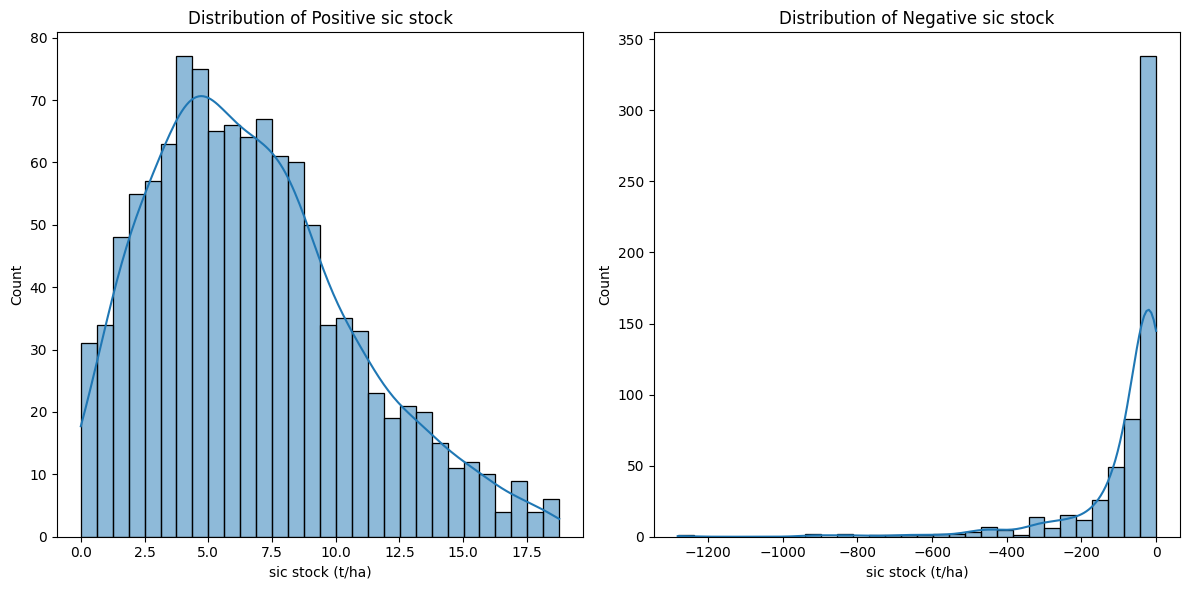

In [40]:
# plot distribution of soc_tha with appropriate scaling
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Create two subplots for positive and negative values
plt.subplot(1, 2, 1)
sns.histplot(data=final_dataset[final_dataset[f'{LABEL}_tha'] >= 0], x=f'{LABEL}_tha', bins=30, kde=True)
plt.title(f"Distribution of Positive {LABEL} stock")
plt.xlabel(f"{LABEL} stock (t/ha)")

plt.subplot(1, 2, 2)
sns.histplot(data=final_dataset[final_dataset[f'{LABEL}_tha'] < 0], x=f'{LABEL}_tha', bins=30, kde=True)
plt.title(f"Distribution of Negative {LABEL} stock")
plt.xlabel(f"{LABEL} stock (t/ha)")

plt.tight_layout()
plt.show()

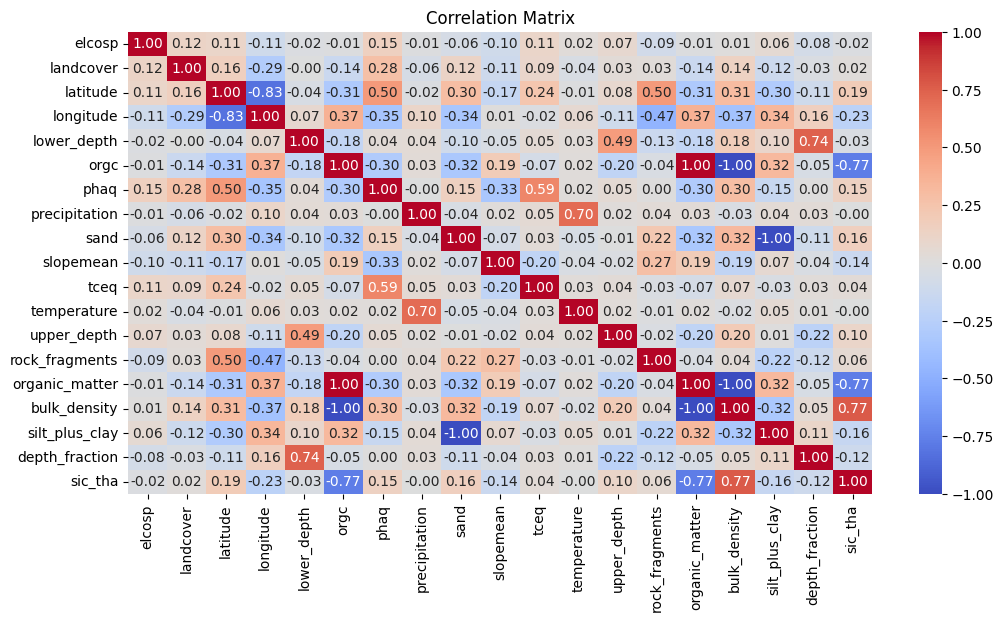

In [41]:
# plot correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

numeric_dataset = final_dataset.select_dtypes(include=['number'])

# Calculate the correlation matrix
corr = numeric_dataset.corr()

# Plot the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

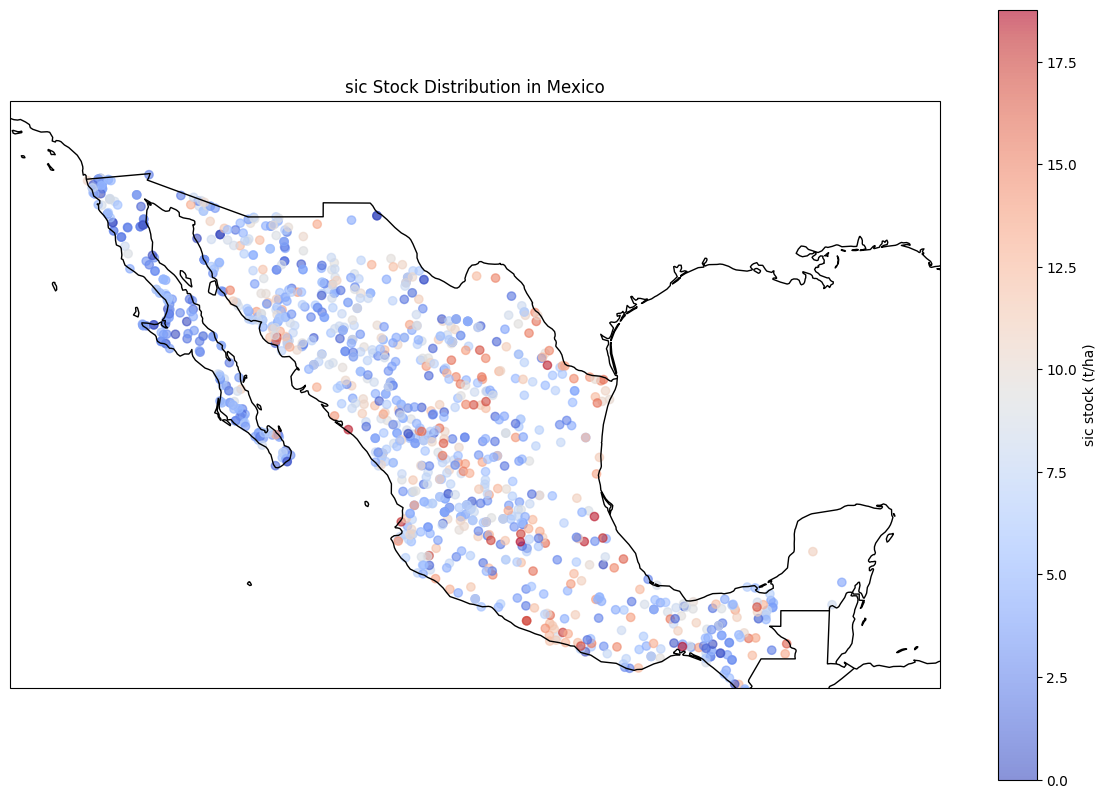

In [42]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Create filtered_data by removing invalid SOC values
filtered_data = final_dataset[
    (final_dataset[f'{LABEL}_tha'].notna()) &  # Remove NaN values
    (final_dataset[f'{LABEL}_tha'] >= 0) # Remove negative values
]

# Create figure and axes with Mercator projection
plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.Mercator())

# Add coastlines and borders
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)

# Set the extent of the map to cover Mexico
ax.set_extent([-120, -85, 15, 35], crs=ccrs.PlateCarree())

# Create scatter plot of SOC stock
scatter = ax.scatter(filtered_data['longitude'], 
                    filtered_data['latitude'],
                    c=filtered_data[f'{LABEL}_tha'],
                    cmap='coolwarm',
                    transform=ccrs.PlateCarree(),
                    alpha=0.6)

# Add colorbar
plt.colorbar(scatter, label=f'{LABEL} stock (t/ha)')

# Add title
plt.title(f'{LABEL} Stock Distribution in Mexico')

plt.show()

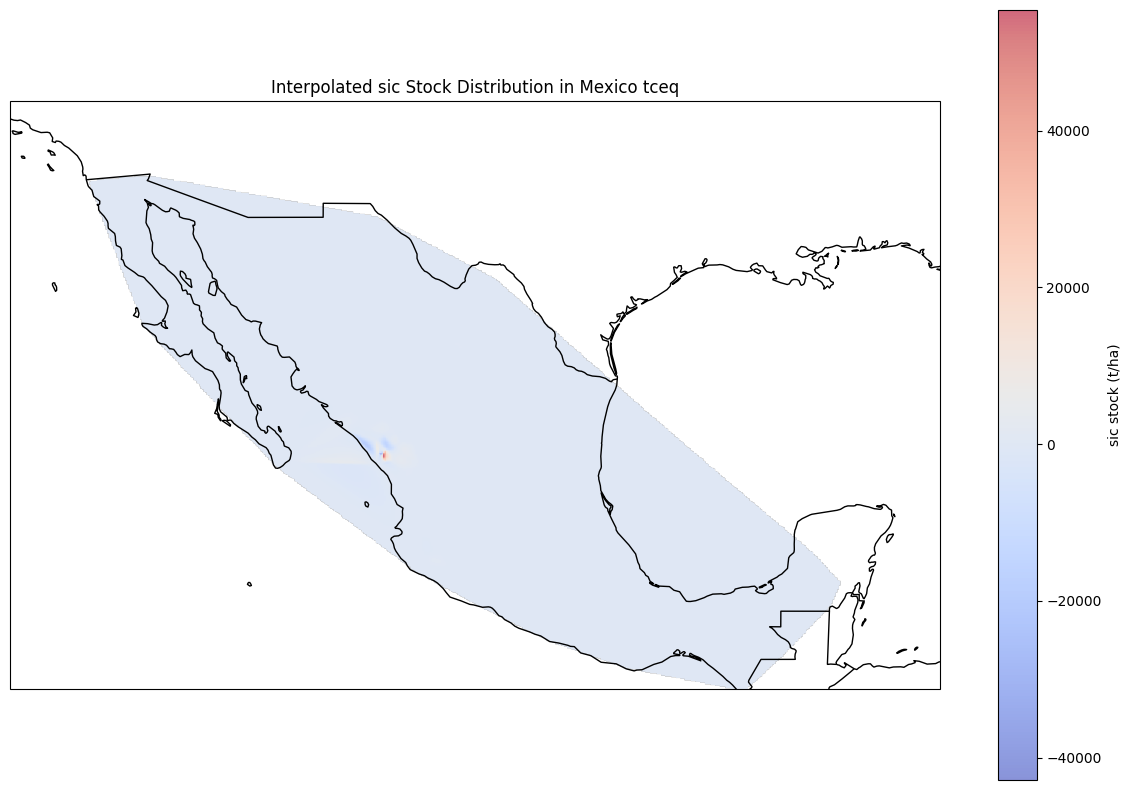

In [43]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from scipy.interpolate import griddata

# Create filtered_data by removing invalid SOC values
filtered_data = final_dataset[
    (final_dataset[f'{LABEL}_tha'].notna()) &  # Remove NaN values
    (final_dataset[f'{LABEL}_tha'] >= 0) # Remove negative values
]

# Extract latitude, longitude, and SOC stock values
latitudes = filtered_data['latitude'].values
longitudes = filtered_data['longitude'].values
soc_values = filtered_data[f'{LABEL}_tha'].values

# Define grid for interpolation
grid_lon, grid_lat = np.meshgrid(
    np.linspace(longitudes.min(), longitudes.max(), 500),
    np.linspace(latitudes.min(), latitudes.max(), 500)
)

# Interpolate SOC values on the grid
grid_soc = griddata(
    (longitudes, latitudes), soc_values,
    (grid_lon, grid_lat), method='cubic'
)

# Create figure and axes with Mercator projection
plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.Mercator())

# Add coastlines and borders
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)

# Set the extent of the map to cover Mexico
ax.set_extent([-120, -85, 15, 35], crs=ccrs.PlateCarree())

# Plot the interpolated SOC values as a heatmap
heatmap = ax.imshow(grid_soc, extent=[longitudes.min(), longitudes.max(), latitudes.min(), latitudes.max()],
                    origin='lower', cmap='coolwarm', transform=ccrs.PlateCarree(), alpha=0.6)

# Add colorbar
plt.colorbar(heatmap, label=f'{LABEL} stock (t/ha)')

# Add title
plt.title(f'Interpolated {LABEL} Stock Distribution in Mexico {TARGET}')

plt.show()

In [44]:
# rename zone_number to ecoregion
final_dataset = final_dataset.rename(columns={'zone_number': 'ecoregion'})

# remove missing values
final_dataset = final_dataset.dropna()
print("Shape of the dataset after removing missing values:", final_dataset.shape)

# remove duplicate rows
final_dataset = final_dataset.drop_duplicates()
print("Shape of the dataset after removing duplicate rows:", final_dataset.shape)

# save dataset
final_dataset_path = f"D:/tierra/datasets/mexico_{TARGET}_{LABEL}_tha_dataset.csv"
final_dataset.to_csv(final_dataset_path, index=False)
print("Saved to file", final_dataset_path)

# display dataset
final_dataset.head()

Shape of the dataset after removing missing values: (1701, 24)
Shape of the dataset after removing duplicate rows: (1701, 24)
Saved to file D:/tierra/datasets/mexico_tceq_sic_tha_dataset.csv


,bedrock,date,ecoregion,elcosp,geometry,landcover,latitude,longitude,lower_depth,orgc,phaq,precipitation,sand,slopemean,soil_type,tceq,temperature,upper_depth,rock_fragments,organic_matter,bulk_density,silt_plus_clay,depth_fraction,sic_tha
0,rocas_igneas,11/14/2003,2,0.0,POINT (-99.68626 16.71785),17.0,16.717850,-99.686264,30,3.0,5.3,22.056425,92.0,0.150130,SOLONCHAK GLEYICO,0.0,13.048712,0,0.009315,5.172,1.30968,8.0,30,11.786022
1,rocas_igneas,9/18/2002,7,0.1,POINT (-104.65806 19.17316),2.0,19.173162,-104.658060,12,8.0,6.6,163.591797,95.0,0.796442,REGOSOL EUTRICO,0.0,16.481157,0,6.378134,13.792,0.79248,5.0,12,7.122572
2,rocas_igneas,11/13/2003,2,0.1,POINT (-98.49142 18.89119),8.0,18.891191,-98.491420,30,3.0,6.1,22.056425,90.0,1.919764,FLUVISOL EUTRICO,0.0,13.048712,0,6.225403,5.172,1.30968,10.0,30,11.053324
3,rocas_igneas,8/26/2003,2,0.8,POINT (-104.8642 21.07363),10.0,21.073630,-104.864200,13,31.0,6.6,155.092468,82.0,5.415294,REGOSOL EUTRICO,0.0,16.817062,0,9.413166,53.444,-1.58664,18.0,13,-57.922664
4,rocas_igneas,8/23/2003,2,0.1,POINT (-105.04132 20.84146),12.0,20.841465,-105.041320,8,6.0,5.9,155.092468,90.0,1.690705,FEOZEM HAPLICO,0.0,16.817062,0,12.961844,10.344,0.99936,10.0,8,4.175158


In [45]:
# load final dataset
final_dataset_path = f"D:/tierra/datasets/mexico_{TARGET}_{LABEL}_tha_dataset.csv"
final_dataset = pd.read_csv(final_dataset_path)

# Define column types
numeric_cols = ['elcosp', 'phaq', 'precipitation', 'sand', 'slopemean', 'temperature', 'silt_plus_clay']
categorical_cols = ['landcover', 'ecoregion']
label_cols = ['bedrock', 'soil_type']
drop_columns = ['date', 'latitude', 'longitude', 'geometry', 'bulk_density', 'organic_matter', 
               'depth_fraction', 'rock_fragments', TARGET]
target_column = f'{LABEL}_tha'

final_dataset = final_dataset.drop(columns=drop_columns, errors='ignore')
print(final_dataset.columns)

Index(['bedrock', 'ecoregion', 'elcosp', 'landcover', 'lower_depth', 'orgc',
       'phaq', 'precipitation', 'sand', 'slopemean', 'soil_type',
       'temperature', 'upper_depth', 'silt_plus_clay', 'sic_tha'],
      dtype='object')



Baseline Model:
MSE: 7249.5874
MAE: 44.1453
R2: -0.0001


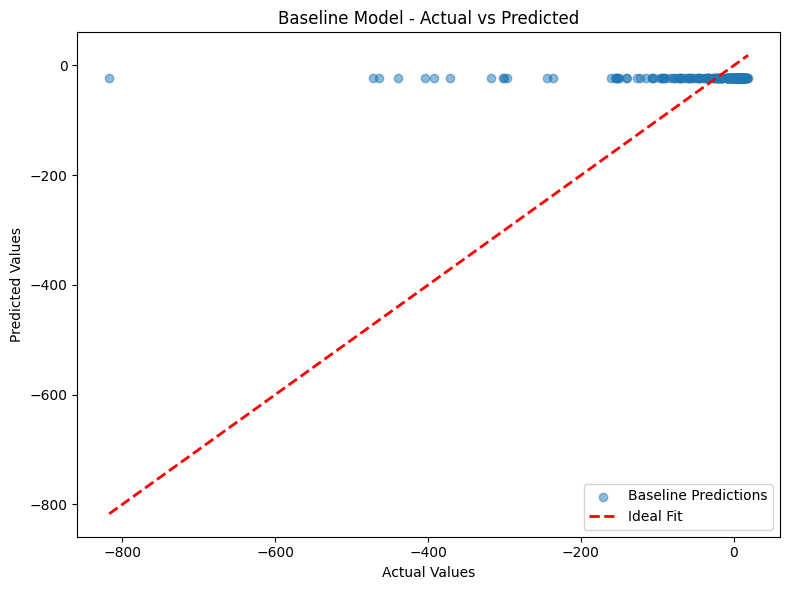


Training Random Forest...
MSE: 5855.3804
MAE: 34.0797
R2: 0.1922


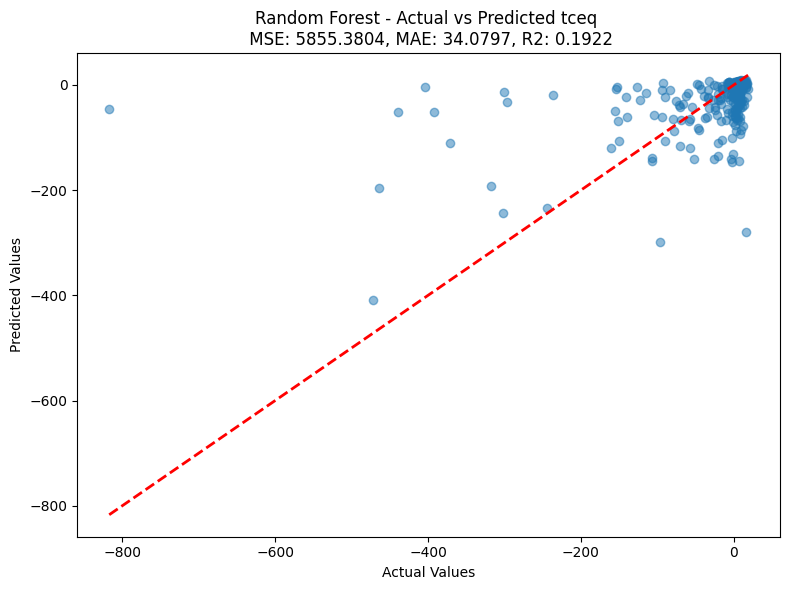

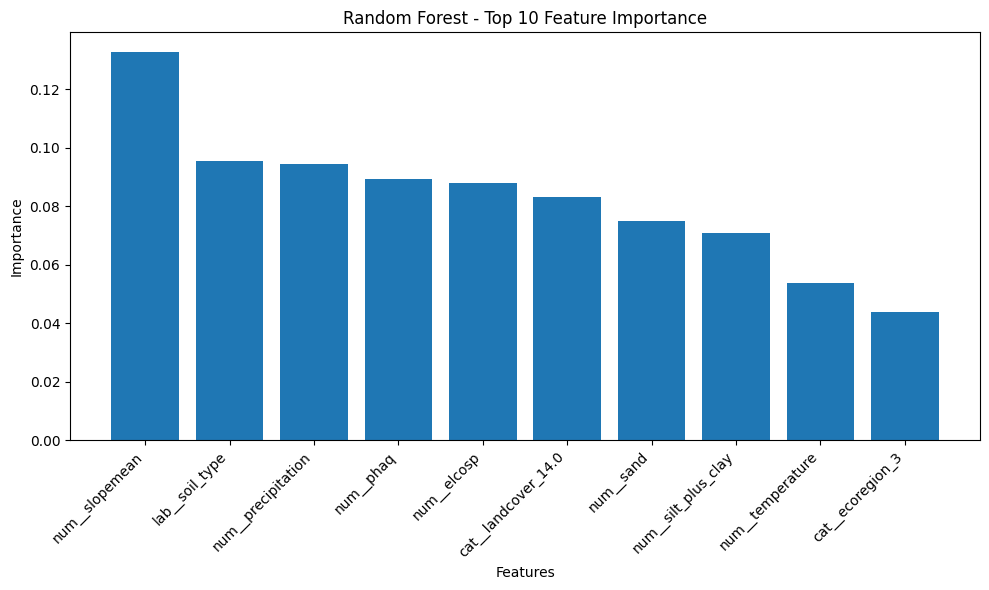


Training Gradient Boosting...
MSE: 6088.7556
MAE: 34.1919
R2: 0.1601


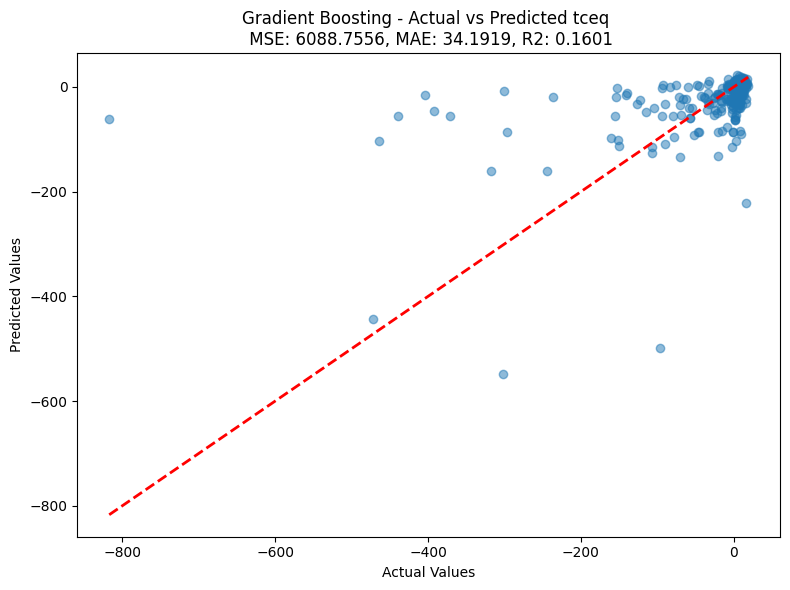

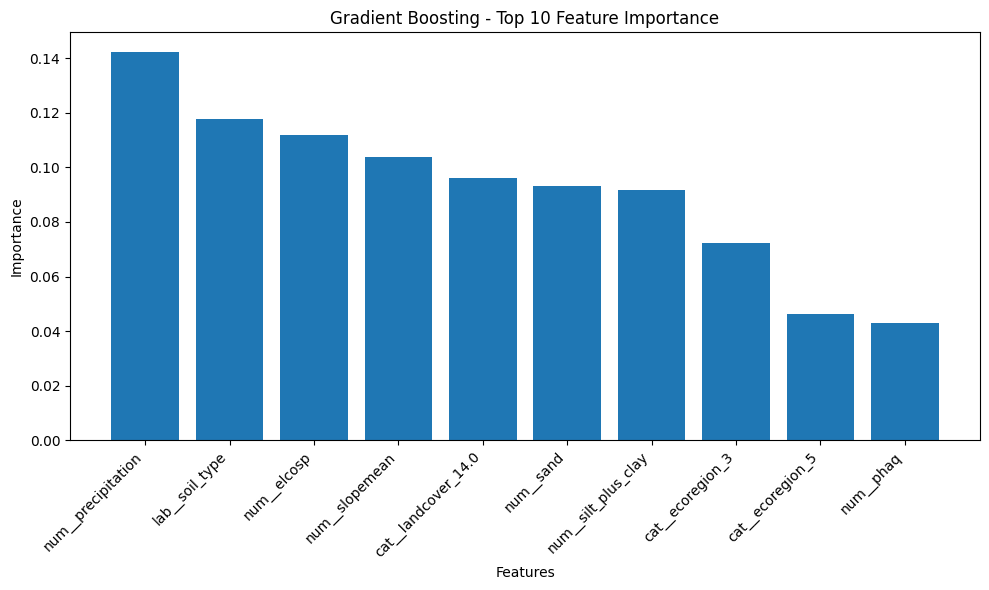


Training MLP...
MSE: 6994.0772
MAE: 37.7525
R2: 0.0352


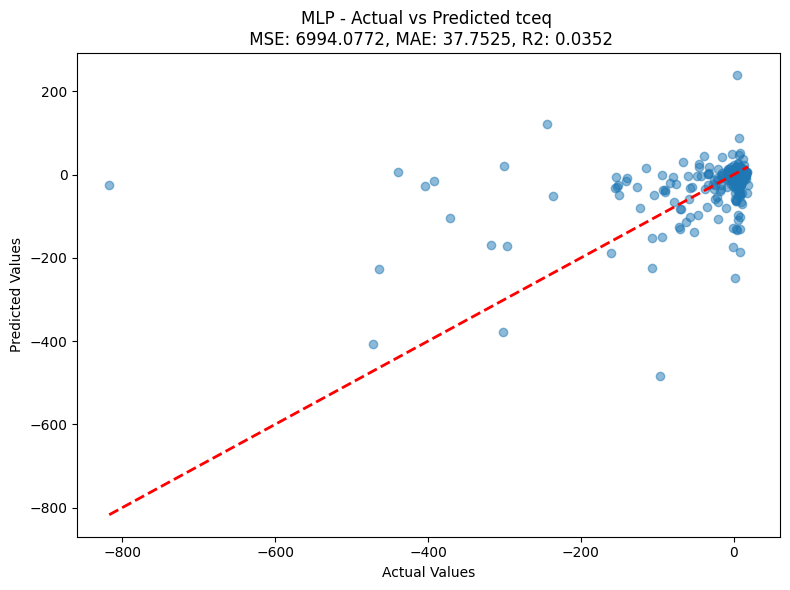

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Split data first (avoids leakage)
train_df, test_df = train_test_split(final_dataset, test_size=0.2, random_state=42)

# Preprocessing pipeline
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
label_transformer = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols),
    ('lab', label_transformer, label_cols)
])

# Fit and transform the data
X_train = preprocessor.fit_transform(train_df.drop(columns=[target_column]))
y_train = train_df[target_column].values
X_test = preprocessor.transform(test_df.drop(columns=[target_column]))
y_test = test_df[target_column].values

# Baseline model (predicting mean value)
y_baseline = np.full_like(y_test, np.mean(y_train))

# Calculate baseline metrics
baseline_mse = mean_squared_error(y_test, y_baseline)
baseline_mae = mean_absolute_error(y_test, y_baseline)
baseline_r2 = r2_score(y_test, y_baseline)

print("\nBaseline Model:")
print(f"MSE: {baseline_mse:.4f}")
print(f"MAE: {baseline_mae:.4f}")
print(f"R2: {baseline_r2:.4f}")

# Plot baseline predictions
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_baseline, alpha=0.5, label='Baseline Predictions')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2, label='Ideal Fit')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Baseline Model - Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

# Initialize models
models = {
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'MLP': MLPRegressor(random_state=42, max_iter=1000, hidden_layer_sizes=(100, 50))
}

# Train and evaluate models
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")
    
    # Plot actual vs predicted
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{name} - Actual vs Predicted {TARGET} \n MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}')
    plt.tight_layout()
    plt.show()
    
    # Plot feature importance for tree-based models
    if hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
        feature_names = preprocessor.get_feature_names_out()
        feat_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
        feat_importance.sort_values(by='Importance', ascending=False, inplace=True)
        
        plt.figure(figsize=(10, 6))
        plt.bar(feat_importance['Feature'][:10], feat_importance['Importance'][:10])
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('Features')
        plt.ylabel('Importance')
        plt.title(f'{name} - Top 10 Feature Importance')
        plt.tight_layout()
        plt.show()